# Analyzing CoCiP internal processes

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# Import each CoCiP bypass dataset into a dictionary, similar to epm_bypass_data
cocip_bypass_files = {
    '110T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass.nc",
    '110T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-bypass.nc",
    '110T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T225L25/110T225L25-bypass.nc",
    '130T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T205L25/130T205L25-bypass.nc",
    '130T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T218L25/130T218L25-bypass.nc",
    '130T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass.nc",
}

# Open each CoCiP bypass dataset and store in a dictionary for easy access
cocip_bypass_data = {}
for test_id, filepath in cocip_bypass_files.items():
    cocip_bypass_data[test_id] = xr.open_dataset(filepath)

In [3]:
cocip_bypass_data['110T218L25']  # Example access to a specific dataset

<xarray.Dataset>
Dimensions:                    (index: 575)
Coordinates:
  * index                      (index) int64 0 1 3 6 ... 79461 79623 79785 79947
Data variables: (12/57)
    waypoint                   (index) int64 ...
    flight_id                  (index) <U3 ...
    formation_time             (index) datetime64[ns] ...
    time                       (index) datetime64[ns] ...
    age                        (index) timedelta64[ns] ...
    longitude                  (index) float64 ...
    ...                         ...
    rf_net                     (index) float64 ...
    persistent                 (index) bool ...
    ef                         (index) float64 ...
    timestep                   (index) int64 ...
    age_hours                  (index) float64 ...
    dt_integration             (index) timedelta64[ns] ...

# Crystal Density Investigation Plots

## Lagg and Lturb

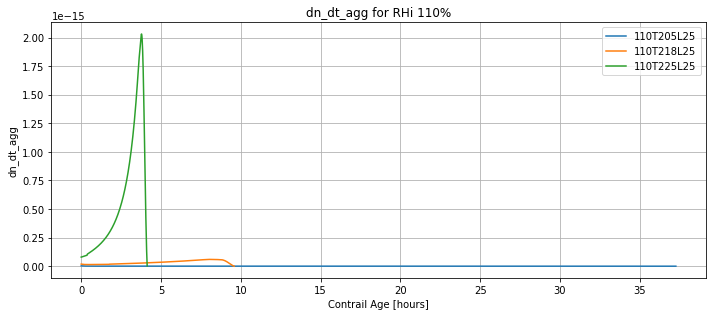

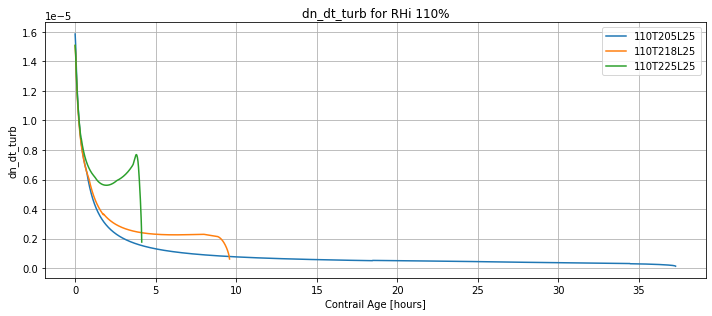

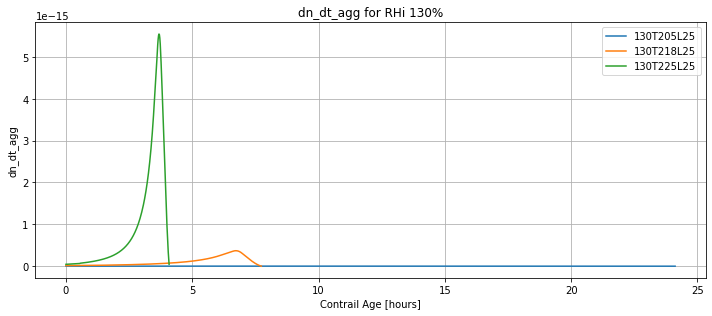

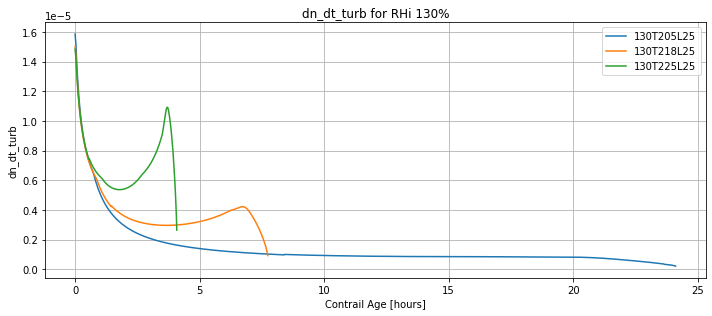

In [4]:
# Plot dn_dt_agg and dn_dt_turb for RHi groups 110 and 130
vars_to_plot = ['dn_dt_agg', 'dn_dt_turb']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel(var)
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Terminal crystal velocity

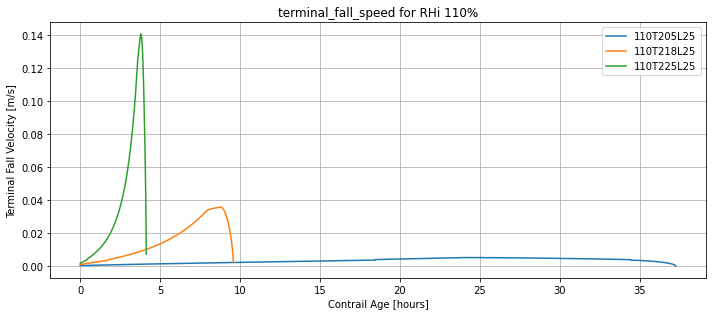

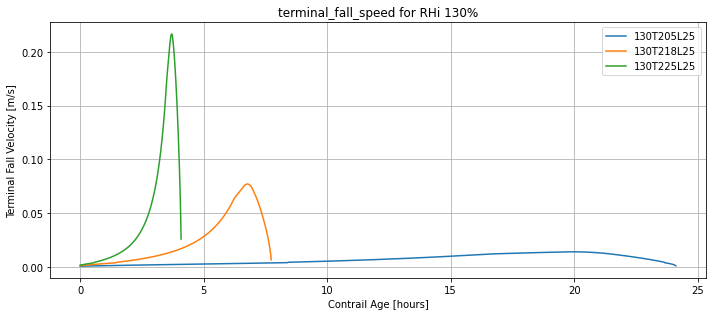

In [5]:
# Plot terminal crystal velocity for RHi groups 110 and 130
vars_to_plot = ['terminal_fall_speed']
rhi_groups = ['110', '130']

for rhi in rhi_groups:
    # select tests that start with the RHi prefix (e.g. '110T205L25')
    tests = [k for k in cocip_bypass_data.keys() if k.startswith(rhi)]

    for var in vars_to_plot:
        plt.figure(figsize=(10, 4.5))
        plotted = False
        for test_id in tests:
            ds = cocip_bypass_data[test_id]

            # use the dataset's index coordinate if available
            x = ds['age_hours'].values

            y = ds[var].values
            plt.plot(x, y, label=test_id)
            plotted = True

        plt.xlabel('Contrail Age [hours]')
        plt.ylabel('Terminal Fall Velocity [m/s]')
        plt.title(f"{var} for RHi {rhi}%")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [6]:
# Print the time and index of the 